##**ML Final Exam**
**Name:** Mustofa Kamal Jabed

**Email:** jabed5564@gmail.com

##0. Importing necessary libraries

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

##1. Data Loading

In [2]:
path = kagglehub.dataset_download("ninzaami/loan-predication")
print("Path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'loan-predication' dataset.
Path: /kaggle/input/loan-predication
['train_u6lujuX_CVtuZ9i (1).csv']


In [3]:
df = pd.read_csv(path + "/train_u6lujuX_CVtuZ9i (1).csv")

In [4]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [5]:
print(df.shape)

(614, 13)


##2. Data Preprocessing

#### 1. Check missing values

In [6]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


#### 2. Handle missing values
##### Fill categorical with mode

In [7]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

##### Fill numerical with median

In [8]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [9]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [10]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#### 3. Drop unnecessary column

In [11]:
df.drop('Loan_ID', axis=1, inplace=True)

#### 4. Encoding categorical features



In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)


#### 5. Separate features and target

In [13]:
X = df_encoded.drop('Loan_Status_Y', axis=1)
y = df_encoded['Loan_Status_Y']

#### 6. Train-test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### 7. Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##3. Pipeline Creation

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

* A machine learning pipeline was created
* It includes preprocessing and model steps
* Scaling and Random Forest model were combined

##4. Primary Model Selection

* Random Forest was selected as the primary model
* It can handle non-linear relationships effectively
* It works well with both numerical and categorical features
* It is robust to noise and reduces overfitting using multiple trees

##5. Model Training

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

##6. Cross Validation

In [18]:
scores = cross_val_score(pipeline, X, y, cv=5)

print(f"Mean Accuracy: {scores.mean():.2f}")
print(f"Standard Deviation: {scores.std():.2f}")

Mean Accuracy: 0.79
Standard Deviation: 0.03


* 5-fold cross validation was used to evaluate the model
* The average accuracy and standard deviation were calculated
* The model shows consistent performance across different splits

##7. Hyperparameter Tuning

In [19]:
param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1)

grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV Score: {grid.best_score_:.2f}")

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 50}
Best CV Score: 0.79


* Grid Search was used to find the best hyperparameters
* Different combinations of parameters were tested
* The best parameters were selected based on cross-validation score

##8. Best model selection

In [20]:
best_model = grid.best_estimator_

* The best model was selected based on hyperparameter tuning
* It achieved the highest cross-validation score
* This model is used for final evaluation

##9. Model Performance Evaluation

In [21]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")

Accuracy: 0.84
Precision: 0.84
Recall: 0.94


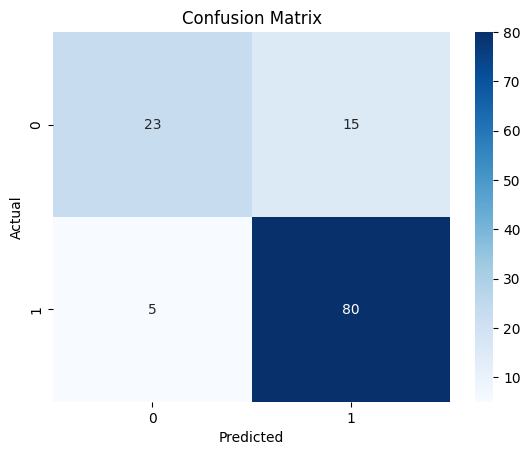

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##10. Gradio Web Interface

In [23]:
def predict(
    Gender, Married, Dependents, Education, Self_Employed,
    ApplicantIncome, CoapplicantIncome, LoanAmount,
    Loan_Amount_Term, Credit_History, Property_Area
):
    input_dict = {
        'ApplicantIncome': ApplicantIncome,
        'CoapplicantIncome': CoapplicantIncome,
        'LoanAmount': LoanAmount,
        'Loan_Amount_Term': Loan_Amount_Term,
        'Credit_History': Credit_History,

        'Gender_Male': 1 if Gender == "Male" else 0,
        'Married_Yes': 1 if Married == "Yes" else 0,
        'Dependents_1': 1 if Dependents == "1" else 0,
        'Dependents_2': 1 if Dependents == "2" else 0,
        'Dependents_3+': 1 if Dependents == "3+" else 0,
        'Education_Not Graduate': 1 if Education == "Not Graduate" else 0,
        'Self_Employed_Yes': 1 if Self_Employed == "Yes" else 0,
        'Property_Area_Semiurban': 1 if Property_Area == "Semiurban" else 0,
        'Property_Area_Urban': 1 if Property_Area == "Urban" else 0
    }

    input_df = pd.DataFrame([input_dict])
    prediction = best_model.predict(input_df)[0]

    return "Approved" if prediction == 1 else "Rejected"


interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Dropdown(["Male", "Female"], label="Gender"),
        gr.Dropdown(["Yes", "No"], label="Married"),
        gr.Dropdown(["0", "1", "2", "3+"], label="Dependents"),
        gr.Dropdown(["Graduate", "Not Graduate"], label="Education"),
        gr.Dropdown(["Yes", "No"], label="Self Employed"),
        gr.Number(label="Applicant Income"),
        gr.Number(label="Coapplicant Income"),
        gr.Number(label="Loan Amount"),
        gr.Number(label="Loan Amount Term"),
        gr.Number(label="Credit History (1 or 0)"),
        gr.Dropdown(["Rural", "Semiurban", "Urban"], label="Property Area")
    ],
    outputs="text",
    title="Loan Approval Prediction"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2d9ec9622058c2697a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
joblib.dump(best_model, "model.pkl")

['model.pkl']